# Notebook_Test

# Simulación básica del flujo de trabajo para mantenimiento predictivo 

# Importaciones: Carga De Librerias: Datos, visualización, Entrenamiento, Evaluación

In [ ]:
from pathlib import Path

import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import accuracy_score, classification_report, confusion_matrix


# Ruta Del Dataset

In [48]:
repo_root = Path.cwd().parent.parent
dataset_path = repo_root / "Mantenimiento_predictivo" / "tests" / "chemical_process_timeseries.csv"

print("Ruta del dataset:", dataset_path)

df = pd.read_csv(dataset_path, sep=",")
print("Dataset carga correctamente")
print("Forma:", df.shape)

Ruta del dataset: c:\Users\SoftwareGameVision\Desktop\Mantenimiento_predictivo\Mantenimiento_predictivo\tests\chemical_process_timeseries.csv
Dataset carga correctamente
Forma: (777600, 21)


# Primeras Filas

In [49]:
df.head()

,timestamp,operating_regime,reactor_id,ambient_temp_effect,reactor_temp,reactor_pressure,feed_flow_rate,coolant_flow_rate,agitator_speed_rpm,reaction_rate,...,selectivity,yield_pct,vibration_rms,motor_current,power_consumption_kw,temp_setpoint,pressure_setpoint,fault_type,efficiency_loss_pct,time_to_fault_min
0,2024-01-01 00:00:00,A,A_R1,0.000000,181.135558,15.791013,101.108882,79.154645,305.779931,0.724542,...,91.927424,82.032893,1.470297,45.882315,41.294083,180.0,12.0,0,0.0,NaN
1,2024-01-01 00:01:00,A,A_R1,0.000485,182.249820,15.706975,98.932369,NaN,302.283603,0.728999,...,91.581466,81.301503,1.425847,46.755905,42.080314,180.0,12.0,0,0.0,NaN
2,2024-01-01 00:02:00,A,A_R1,0.000970,183.129737,15.593397,99.792219,80.593736,305.814440,0.732519,...,91.895056,82.006626,1.448190,NaN,NaN,NaN,12.0,0,NaN,NaN
3,2024-01-01 00:03:00,A,A_R1,0.001454,183.020987,15.527333,99.854222,80.190444,304.436123,0.732084,...,91.544885,81.562261,1.473448,45.862171,41.275954,180.0,12.0,0,0.0,NaN
4,2024-01-01 00:04:00,A,A_R1,0.001939,183.077096,NaN,99.302349,78.571707,304.811418,0.732308,...,92.258005,82.411124,1.523491,46.880227,42.192204,180.0,12.0,0,NaN,NaN


# Columnas

In [50]:
print("Columnas del dataset:")
for col in df.columns:
    print("-", col)

Columnas del dataset:
- timestamp
- operating_regime
- reactor_id
- ambient_temp_effect
- reactor_temp
- reactor_pressure
- feed_flow_rate
- coolant_flow_rate
- agitator_speed_rpm
- reaction_rate
- conversion_rate
- selectivity
- yield_pct
- vibration_rms
- motor_current
- power_consumption_kw
- temp_setpoint
- pressure_setpoint
- fault_type
- efficiency_loss_pct
- time_to_fault_min


# Información General

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 777600 entries, 0 to 777599
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   timestamp             777600 non-null  str    
 1   operating_regime      777600 non-null  str    
 2   reactor_id            777600 non-null  str    
 3   ambient_temp_effect   731039 non-null  float64
 4   reactor_temp          730635 non-null  float64
 5   reactor_pressure      730457 non-null  float64
 6   feed_flow_rate        730840 non-null  float64
 7   coolant_flow_rate     730955 non-null  float64
 8   agitator_speed_rpm    730825 non-null  float64
 9   reaction_rate         730770 non-null  float64
 10  conversion_rate       731184 non-null  float64
 11  selectivity           730391 non-null  float64
 12  yield_pct             731076 non-null  float64
 13  vibration_rms         731141 non-null  float64
 14  motor_current         730983 non-null  float64
 15  power_consu

# Nulos

In [52]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
timestamp                    0
operating_regime             0
reactor_id                   0
ambient_temp_effect      46561
reactor_temp             46965
reactor_pressure         47143
feed_flow_rate           46760
coolant_flow_rate        46645
agitator_speed_rpm       46775
reaction_rate            46830
conversion_rate          46416
selectivity              47209
yield_pct                46524
vibration_rms            46459
motor_current            46617
power_consumption_kw     46494
temp_setpoint            46522
pressure_setpoint        46818
fault_type                   0
efficiency_loss_pct      46919
time_to_fault_min       751313
dtype: int64


# Duplicados

In [53]:
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


# Estadísticas

In [19]:
df.describe()

,ambient_temp_effect,reactor_temp,reactor_pressure,feed_flow_rate,coolant_flow_rate,agitator_speed_rpm,reaction_rate,conversion_rate,selectivity,yield_pct,vibration_rms,motor_current,power_consumption_kw,temp_setpoint,pressure_setpoint,fault_type,efficiency_loss_pct,time_to_fault_min
count,731039.000000,730635.000000,730457.000000,730840.000000,730955.000000,730825.000000,730770.000000,731184.000000,730391.000000,731076.000000,731141.000000,730983.000000,731106.000000,731078.000000,730782.00000,777600.000000,730681.000000,26287.000000
mean,-0.001843,187.966928,16.621244,103.914662,75.941397,299.995083,0.751721,99.352438,91.667593,82.002868,1.509472,46.024157,41.400321,186.002413,12.74955,0.084898,0.539090,477.224217
std,7.070747,6.764989,0.958705,4.299429,4.435884,5.523135,0.026999,0.704188,0.201028,0.403068,0.125159,0.584062,0.460203,6.000004,0.75000,0.494627,2.999595,331.441294
min,-10.000000,177.793913,15.214215,77.477094,57.024631,273.136099,0.711814,88.574898,90.644932,80.398878,1.203509,43.449569,39.104612,180.000000,12.00000,0.000000,0.000000,0.000000
25%,-7.074538,181.114731,15.679560,99.975390,71.981321,296.308714,0.724360,99.043724,91.531879,81.714045,1.463526,45.658747,41.089718,180.000000,12.00000,0.000000,0.000000,199.000000
50%,-0.001697,191.453608,16.026735,102.535852,76.000170,299.983118,0.766517,99.390124,91.667629,82.002136,1.500639,46.005217,41.399793,192.000000,12.00000,0.000000,0.000000,424.000000
75%,7.067510,194.490403,17.557269,107.992742,79.962695,303.688205,0.777871,99.736575,91.803187,82.291000,1.537913,46.356196,41.711413,192.000000,13.50000,0.000000,0.000000,703.000000
max,10.000000,202.349193,18.335542,113.535969,86.263795,330.603218,0.794623,101.112162,92.553263,83.784775,3.617354,52.410077,43.882496,192.000000,13.50000,4.000000,25.000000,1416.000000


# Seleccionar Columnas Útiles

In [55]:
features = [
    "reactor_temp",
    "reactor_pressure",
    "feed_flow_rate",
    "coolant_flow_rate",
    "agitator_speed_rpm"
]

target = "fault_type"

# Comprobar Que Existen

In [59]:
print("Comprobación de features:")
for col in features:
    print(col, " : ", col in df.columns)

print("Target:", target, " : ", target in df.columns)

Comprobación de features:
reactor_temp  :  True
reactor_pressure  :  True
feed_flow_rate  :  True
coolant_flow_rate  :  True
agitator_speed_rpm  :  True
Target: fault_type  :  True


# Limpieza Básica

In [60]:
df_model = df[features + [target]].dropna()

print("Forma despues de limpieza:", df_model.shape)

Forma despues de limpieza: (570121, 6)


# Crear X E y

In [23]:
X = df_model[features]
y = df_model[target]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

X.head()

Forma de X: (570121, 5)
Forma de y: (570121,)


,reactor_temp,reactor_pressure,feed_flow_rate,coolant_flow_rate,agitator_speed_rpm
0,181.135558,15.791013,101.108882,79.154645,305.779931
2,183.129737,15.593397,99.792219,80.593736,305.814440
3,183.020987,15.527333,99.854222,80.190444,304.436123
6,182.841240,15.836389,100.681247,80.726173,300.562559
7,182.587322,15.448385,101.109490,79.484674,298.963240


# Distribución Del Target

In [38]:
print(y.value_counts())

fault_type
0    549755
1      6698
4      5391
2      5021
3      3256
Name: count, dtype: int64


# División Train Y Test

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (456096, 5)
X_test: (114025, 5)
y_train: (456096,)
y_test: (114025,)


# Entrenar Modelo Simple

In [42]:
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


# Predicciones

In [43]:
y_pred = modelo.predict(X_test)

# Accuracy

In [44]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9783731637798728


# Reporte De Clasificación

In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    109952
           1       0.93      0.60      0.73      1340
           2       0.97      0.78      0.86      1004
           3       0.71      0.21      0.33       651
           4       0.00      0.00      0.00      1078

    accuracy                           0.98    114025
   macro avg       0.72      0.52      0.58    114025
weighted avg       0.97      0.98      0.97    114025



c:\Users\SoftwareGameVision\Desktop\Mantenimiento_predictivo\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\SoftwareGameVision\Desktop\Mantenimiento_predictivo\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\SoftwareGameVision\Desktop\Mantenimiento_predictivo\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

# Matriz De Confusión

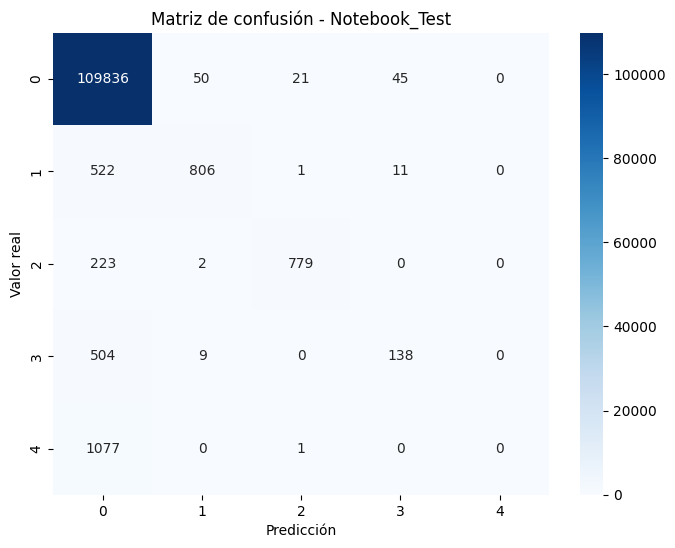

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap=" Blues ")
plt.title(" Matriz de confusión - Notebook_Test ")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()